<a href="https://colab.research.google.com/github/LongBaoNguyen/longbaonguyen.github.io/blob/master/courses/apcsp/image_processing/image_processing_lab/image_processing_lect_lab.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

# Images and Their Pixels Lab


In [1]:
# run this to import numpy and matplotlib
import numpy as np
import matplotlib.pyplot as plt




#### Create a numpy array representing an RGB image shown below. The dimensions are 100 pixels by 100 pixels. Hint: Use np.zeros(shape_tuple, dtype="uint8").

#### You'll need to use slicing to initialize your array. For example: array[: ,: ,0] = 255 would set the Red component of all pixels to its maximum value of 255.

#### Then use the following code to plot this image.

```python
img = np.zeros(100, 100, dtype="uint8")
plt.imshow(my_image)
plt.axis('off')
plt.show()

```

# ![alt text](https://github.com/LongBaoNguyen/longbaonguyen.github.io/blob/master/courses/apcsp/image_processing/image_processing_lab/pattern.png?raw=1)

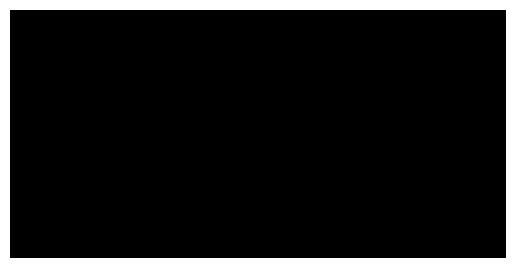

In [8]:
img = np.zeros((100, 200, 3), dtype="uint8")
plt.imshow(img)
plt.axis('off')
plt.show()

Run the cell below to read the image from the class website.

Then use the code below to plot this image.

```python
plt.imshow(my_image)
plt.axis('off')
plt.show()
```

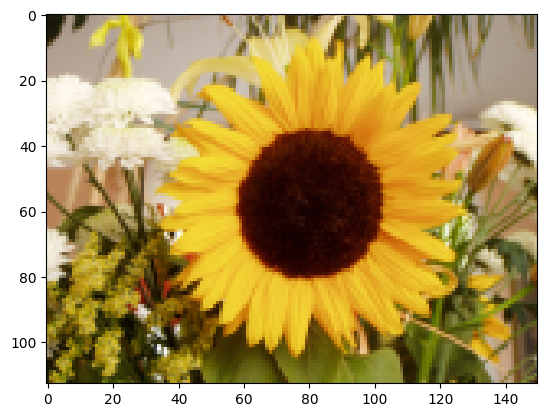

In [19]:
# Run this cell

from PIL import Image
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/LongBaoNguyen/longbaonguyen.github.io/master/courses/apcsp/datasets/sunflower.png"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img = np.asarray(img).astype(np.float32) / 255.0  # shape: (H, W)
plt.imshow(img)
plt.axis('on')
plt.show()


#### What is the width and height of the image? The type of data? (img.dtype).

In [15]:
img.dtype

dtype('float32')

#### Print out any pixel. Note that the pixel values are 32-bit floats in the range [0.0, 1.0].

In [16]:
img[50, 50]

array([0.87058824, 0.5803922 , 0.10980392], dtype=float32)

#### Estimate the location of a yellow petal pixel and print out its RGB components. You should see high red(close to 1.0) and green and low blue(close to 0.0).

In [20]:
img[80, 20]

array([0.3529412 , 0.3019608 , 0.00784314], dtype=float32)

#### Use slicing to create a new img(numpy array) consists of the top left quarter of the image. Display this new image.

#### Use slicing to crop out only the sunflower, removing all of the background. Try to get as close as possible. Display the new image.

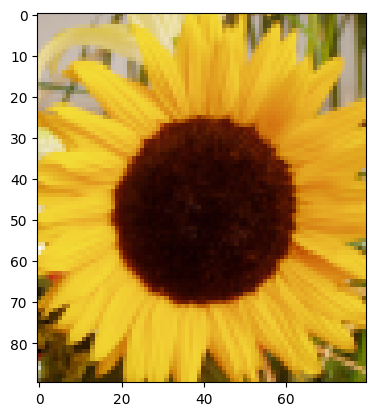

In [23]:
newimg = img[10:100,40:120]
plt.imshow(newimg)
plt.axis('on')
plt.show()

#### Use the average method to convert the sunflower to grayscale. When display the image, use the keyword argument cmap="gray" in imshow() to specify the grayscale colormap.

#### Use the luminosity method to create the grayscale image. Then plot it.

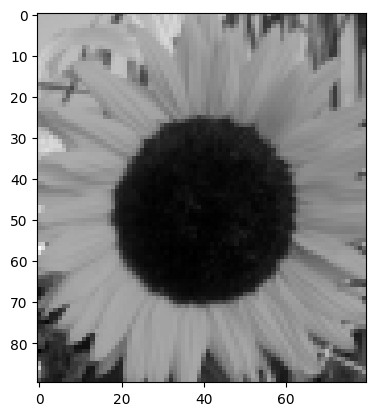

In [29]:
newimg = img[10:100,40:120]
red = newimg[:,:,0]
green = newimg[:,:,1]
blue = newimg[:,:,2]
ave = (red + green + blue)/3
plt.imshow(ave, cmap = "gray")
plt.axis('on')
plt.show()

#### To tint an image is to mix its colors with white. This will increase the lightness of the image. Write a Python function, which takes an image and a percentage value as a parameter. Setting 'percentage' to 0 will not change the image, setting it to one means that the image will be completely whitened.

#### For example, suppose a pixel with RGB components of [0.80, 0.60, 0.40]. Tinting it by 25% means that the pixel is now [0.85, 0.70, 0.55].

#### Hint: Use np.ones(shape). The formula for one pixel in the above example is:

tinted_pixel = [0.80, 0.60, 0.40] + ([1.0, 1.0, 1.0] - [0.80, 0.60, 0.40]) * 0.25

In [33]:
def tint(image, percent):
    """
    imag: the image which will be tinted
    percent: a value between 0 (image will remain unchanged
             and 1 (image will completely white)
    Formula: tinted_image = image + (ones_matrix - image) * percent
    where ones_matrix is matrix of all ones with the same shape as
    the given image. Use np.ones(shape).
    """
    # just add one line of code.
    tinted_image = [0.80, 0.60, 0.40] + ([1.0, 1.0, 1.0] - [0.80, 0.60, 0.40]) * percent
    return tinted_image



In [35]:
tintimg = tint(img, 20)
plt.imshow(tintimg)
plt.axis('on')
plt.show()

TypeError: unsupported operand type(s) for -: 'list' and 'list'

#### If your tint() function is written correctly above, run the code below to see the tinting at three different levels: 20%, 40%, 80%. Play around with different tint levels.

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
tinted_10 = tint(img, 0.20)
tinted_40 = tint(img, 0.40)
tinted_80 = tint(img, 0.80)
axs[0].imshow(tinted_10)
axs[0].set_title("Tinted 20%")
axs[1].imshow(tinted_40)
axs[1].set_title("Tinted 40%")
axs[2].imshow(tinted_80)
axs[2].set_title("Tinted 80%")
